In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib import patches
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Polygon
from matplotlib import animation
import sunpy
import sunpy.map
from sunpy.map import make_fitswcs_header
from sunpy.coordinates import (propagate_with_solar_surface, get_earth)
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from streamtracer import StreamTracer, VectorGrid
from extrapolater import PotentialField
from helpers import from_local
from scipy.spatial import cKDTree
from tqdm.notebook import tqdm
import pickle

import h5py 
import dask.array as da 
from ndcube import NDCube
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs
from fancy_colorbar import plot_colorbar, wcs_scalebar
from IPython.display import HTML, display

import sys
sys.path.append("/cluster/home/zhuyin/scripts/MHSXtraPy/")

from mhsxtrapy.b3d import WhichSolution
from mhsxtrapy.examples import multipole
from mhsxtrapy.field2d import Field2dData, FluxBalanceState, check_fluxbalance
from mhsxtrapy.field3d import calculate_magfield, Field3dData
from mhsxtrapy.plotting.vis import (
    plot_ddensity_xy,
    plot_ddensity_z,
    plot_dpressure_xy,
    plot_dpressure_z,
    plot_magnetogram_2D,
    plot_magnetogram_3D,
)

In [2]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif',
                 'font.serif': ['Computer Modern Roman'], 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

In [3]:
def colored_line_with_alpha(x, y, c, ax, norm_color, norm_alpha, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt", "rasterized": True}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    cmap = plt.get_cmap(default_kwargs.pop("cmap", "plasma"))
    color_rgb = cmap(norm_color(c))
    color_rgb[:,-1] = 1 - norm_alpha(c)*0.9

    lc = LineCollection(segments, colors=color_rgb, **default_kwargs)
    # lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [4]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [5]:
file_hri_pr_noproj_dset = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/HRIEUV_noproj_pr.hdf5")
hri_pr_noproj_array = file_hri_pr_noproj_dset["hrieuv_noproj_img"][:]
hrieuv_no_proj_extent = np.load("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hrieuv_no_proj_extent.npy")
hrieuv_nocrop_noproj_wcs = WCS(fits.getheader("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hri_nocrop_noproj_wcs.fits",
                                        ignore_missing_simple=True))
hrieuv_noproj_wcs = hrieuv_nocrop_noproj_wcs[hrieuv_no_proj_extent[1]:hrieuv_no_proj_extent[3] + 1,
                                hrieuv_no_proj_extent[0]:hrieuv_no_proj_extent[2] + 1]
hrieuv_date_ear = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])

In [6]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

2026-05-13 14:41:25 - synthesizAR - WARNING: File may have been truncated: actual file length (25920) is smaller than the expected size (67135680)
Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
2026-05-13 14:41:25 - synthesizAR - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.791095 from DATEREF.
Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'.
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2026-05-13 14:41:26 - synthesizAR - WARNING: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -156.256400 from OBSGEO-[XYZ].
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'.


In [7]:
data3d = Field3dData.load("../../data/pid_1_123_aux/MHSXtra_results/SOTSP_test_full_v2/")

nx, ny, nz, nf = 960, 536, 536, 536
# xmin, xmax, ymin, ymax, zmin, zmax = 0.0, 1.0, 0.0, 1.0, 0.0, 1.0

pixelsize_x = 0.23712652199468398
pixelsize_y = pixelsize_x
pixelsize_z = pixelsize_x

# x_arr = np.linspace(xmin, xmax, nx, dtype=np.float64)
# y_arr = np.linspace(ymin, ymax, ny, dtype=np.float64)
# z_arr = np.linspace(zmin, zmax, nz, dtype=np.float64)
x_arr = np.arange(nx) * pixelsize_x
y_arr = np.arange(ny) * pixelsize_y
z_arr = np.arange(nz) * pixelsize_z

bx_extra = data3d.field[:,:,:,1]
by_extra = data3d.field[:,:,:,0]
bz_extra = data3d.field[:,:,:,2]

bx_extra = bx_extra[ny:ny*2, nx:nx*2,:]
by_extra = by_extra[ny:ny*2, nx:nx*2,:]
bz_extra = bz_extra[ny:ny*2, nx:nx*2,:]

field_array = np.array([bx_extra.transpose(1,0,2), by_extra.transpose(1,0,2), bz_extra.transpose(1,0,2)]).transpose(1,2,3,0)

field_grid = VectorGrid(field_array, grid_coords=[x_arr, y_arr, z_arr])

In [8]:
x_select = x_arr[420:590]
y_select = y_arr[220:380]
mesh_X, mesh_Y = np.meshgrid(x_select, y_select)
pts = np.column_stack((mesh_X.ravel(), mesh_Y.ravel()))
weights = np.sqrt(np.abs(bz_extra[220:380,420:590,0].T)).ravel()
weights = weights/np.sum(weights) + 1e-30

In [9]:
seeds_test = np.load("../../sav/sotsp_seeds.npy")

In [10]:
nsteps = 10000
step_size = 0.02
tracer = StreamTracer(nsteps, step_size)
tracer.trace(seeds_test, field_grid)

In [12]:
vbi_wcs = unwrap_wcs_to_fitswcs(dkist_vbi_target_cube_crop.wcs)[0]

In [24]:
vbi_dummy_map = sunpy.map.Map(np.zeros((3840,3840), dtype=int), vbi_wcs)
hri_pr_noproj_dummy_map = sunpy.map.Map(np.zeros((hri_pr_noproj_array.shape[1:]), dtype=int), hrieuv_noproj_wcs)

In [25]:
vbi_bottom_left = vbi_dummy_map.bottom_left_coord
vbi_top_right = vbi_dummy_map.top_right_coord
vbi_observer_coord = vbi_dummy_map.observer_coordinate

hri_pr_noproj_bottom_left = hri_pr_noproj_dummy_map.bottom_left_coord
hri_pr_noproj_top_right = hri_pr_noproj_dummy_map.top_right_coord
hri_pr_noproj_observer_coord = hri_pr_noproj_dummy_map.observer_coordinate

2026-05-13 15:02:07 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,dsun_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]
2026-05-13 15:02:07 - sunpy - WARNING: SunpyMetadataWarning: Missing metadata for observer: assuming Earth-based observer.
For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,dsun_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs



INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


In [28]:
hri_pr_noproj_dummy_map.rotation

array([[ 0.99683733, -0.07946911],
       [ 0.07946911,  0.99683733]])

In [29]:
def pcij_to_crota2(pcij, cdelt):
    # Calculate CROTA2 (deg) from PCi_j, accounting for unequal cdelt1/cdelt2.
    cdelt1, cdelt2 = np.asarray(cdelt, dtype=float)
    if cdelt1 == 0 or cdelt2 == 0:
        raise ValueError("cdelt values must be non-zero")

    # Two equivalent angle estimates from the scaled matrix terms.
    theta1 = np.arctan2(pcij[1, 0] * cdelt2, pcij[0, 0] * cdelt1)
    theta2 = np.arctan2(-pcij[0, 1] * cdelt1, pcij[1, 1] * cdelt2)

    # Circular mean keeps the result stable when wrapped near +-pi.
    theta_rad = np.arctan2(np.sin(theta1) + np.sin(theta2),
                           np.cos(theta1) + np.cos(theta2))
    return np.degrees(theta_rad)

In [33]:
hri_crota2 = pcij_to_crota2(hri_pr_noproj_dummy_map.rotation_matrix, hri_pr_noproj_dummy_map.wcs.wcs.cdelt)
vbi_crota2 = pcij_to_crota2(vbi_dummy_map.rotation_matrix, vbi_dummy_map.wcs.wcs.cdelt)

In [36]:
vbi_fovx, vbi_fovy = vbi_dummy_map.scale.axis1*3840*u.pix, vbi_dummy_map.scale.axis2*3840*u.pix
hri_fovx, hri_fovy = ((hri_pr_noproj_dummy_map.scale.axis1*hri_pr_noproj_dummy_map.data.shape[1])*u.pix,
                      (hri_pr_noproj_dummy_map.scale.axis2*hri_pr_noproj_dummy_map.data.shape[0])*u.pix
                     )

In [41]:
transition_frame_n = 120

transition_bottom_left_Tx = np.linspace(vbi_bottom_left.Tx, hri_pr_noproj_bottom_left.Tx, transition_frame_n)
transition_bottom_left_Ty = np.linspace(vbi_bottom_left.Ty, hri_pr_noproj_bottom_left.Ty, transition_frame_n)
transition_top_right_Tx = np.linspace(vbi_top_right.Tx, hri_pr_noproj_top_right.Tx, transition_frame_n)
transition_top_right_Ty = np.linspace(vbi_top_right.Ty, hri_pr_noproj_top_right.Ty, transition_frame_n)
transition_observer_hgln = np.linspace(vbi_observer_coord.lon, hri_pr_noproj_observer_coord.lon, transition_frame_n)
transition_observer_hglt = np.linspace(vbi_observer_coord.lat, hri_pr_noproj_observer_coord.lat, transition_frame_n)
transition_observer_radius = np.linspace(vbi_observer_coord.radius, hri_pr_noproj_observer_coord.radius, transition_frame_n)
transition_fovx = np.linspace(vbi_fovx, hri_fovx, transition_frame_n)
transition_fovy = np.linspace(vbi_fovy, hri_fovy, transition_frame_n)

transition_observer_coord = SkyCoord(lon=transition_observer_hgln, lat=transition_observer_hglt,
    radius=transition_observer_radius, frame="heliographic_stonyhurst", obstime=vbi_dummy_map.date,
    observer="Earth")

transition_crota2 = np.linspace(vbi_crota2, hri_crota2, transition_frame_n)*u.deg

transition_wcs_list = []
transition_wcs_naxis = (360,360)

for ii in range(transition_frame_n):
    observer_ = SkyCoord(
        lon=transition_observer_hgln[ii],
        lat=transition_observer_hglt[ii],
        radius=transition_observer_radius[ii],
        frame="heliographic_stonyhurst",
        obstime=vbi_dummy_map.date,
        observer="Earth"
    )

    center_coord_ = SkyCoord(
        (transition_bottom_left_Tx[ii] + transition_top_right_Tx[ii])/2,
        (transition_bottom_left_Ty[ii] + transition_top_right_Ty[ii])/2,
        frame="helioprojective",
        observer=observer_,
    )

    scale_ = u.Quantity((transition_fovx[ii]/transition_wcs_naxis[0],
                        transition_fovy[ii]/transition_wcs_naxis[1]))/u.pix
    
    wcs_header_ = make_fitswcs_header(
        transition_wcs_naxis,
        center_coord_,
        scale=scale_,
        rotation_angle=transition_crota2[ii],
    )

    transition_wcs_list.append(WCS(wcs_header_))

    

  0%|          | 0/120 [00:00<?, ?it/s]

2026-05-13 16:28:49 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-05-13 16:28:49 - matplotlib.animation - INFO: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec libx264 -pix_fmt yuv420p -vf 'crop=trunc(iw/2)*2:trunc(ih/2)*2' -y ../../figs/test_movie/test_transition_frame.mp4


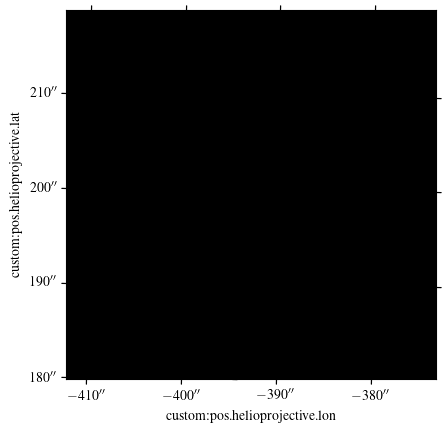

In [43]:
def test_movie(save_dir, fps=30, dpi=100):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=transition_wcs_list[0])
    ax.imshow(np.zeros(transition_wcs_naxis, dtype=int), cmap="gray")
    ax.grid("on", ls=":", lw=1, color="k", alpha=0.5)
    # ax_pos = ax.get_position()

    def update_frame(ii):
        fig.delaxes(fig.axes[0])
        ax = fig.add_subplot(111, projection=transition_wcs_list[ii])
        ax.imshow(np.zeros(transition_wcs_naxis, dtype=int), cmap="gray")
        ax.grid("on", ls=":", lw=1, color="k", alpha=0.5)
        # ax.set_position(ax_pos)
    
    anim = animation.FuncAnimation(fig, update_frame, frames=tqdm(np.arange(transition_frame_n)),
        blit=False)
    anim.save(save_dir, fps=fps, dpi=dpi,writer='ffmpeg', 
    codec='libx264',
    # bitrate=6000,
    extra_args=['-pix_fmt', 'yuv420p',
    '-vf', 'crop=trunc(iw/2)*2:trunc(ih/2)*2'])

    return None

test_movie("../../figs/test_movie/test_transition_frame.mp4")

In [11]:
sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.fits")

fline_hgs = []

for fline in tracer.xs[:]:
    # if fline[-1,2] < 60:
    fline_hgs_ = sotsp_br_map.wcs.pixel_to_world(fline[:,0]/pixelsize_x, fline[:,1]/pixelsize_y)
    fline_hgs_ = SkyCoord(lon=fline_hgs_.lon, lat=fline_hgs_.lat, radius=fline[:,2]*u.Mm + 695700*u.km,
                        frame=fline_hgs_.frame)
    
    fline_hgs.append(fline_hgs_)

fline_vbi_pixel = []

for fline in fline_hgs[:]:
    with propagate_with_solar_surface():
        fline_pixel_x, fline_pixel_y = dkist_vbi_target_cube_crop.wcs.world_to_pixel(fline)
    fline_vbi_pixel.append([fline_pixel_x, fline_pixel_y, fline.radius.to_value(u.Mm) - 695.7])

fline_hri_pixel = []
for fline in fline_hgs[:]:
    with propagate_with_solar_surface():
        fline_pixel_x, fline_pixel_y = hrieuv_noproj_wcs.world_to_pixel(fline)
    fline_hri_pixel.append([fline_pixel_x, fline_pixel_y, fline.radius.to_value(u.Mm) - 695.7])

In [48]:
fline_transition_pixel_list = []

for ii in tqdm(range(transition_frame_n)):
    fline_transition_pixel_ = []
    for fline in fline_hgs:
        with propagate_with_solar_surface():
            fline_pixel_x, fline_pixel_y = transition_wcs_list[ii].world_to_pixel(fline)
        fline_transition_pixel_.append([fline_pixel_x, fline_pixel_y, fline.radius.to_value(u.Mm) - 695.7])
    fline_transition_pixel_list.append(fline_transition_pixel_)

  0%|          | 0/120 [00:00<?, ?it/s]

In [51]:
with open("../../sav/fline_transition_pixel_list.pkl", "wb") as f:
    pickle.dump(fline_transition_pixel_list, f)